# Loading and Inspecting Financial Data

In [ ]:

import yfinance as yf
import pandas as pd


tickers = ['AAPL', 'MSFT', 'GOOG', 'AMZN']
raw_data = yf.download(tickers, start='2020-01-01', end='2025-01-01')


print("Shape of raw data:", raw_data.shape)
print("Index sample (dates):", raw_data.index[:5])
print("Columns (MultiIndex):", raw_data.columns)


close_prices = raw_data['Close'].dropna()


print("\nCleaned Close Price Data")
print("Shape:", close_prices.shape)
print("Index sample:", close_prices.index[:5])
print("Columns:", close_prices.columns)

close_prices.tail()


C:\Users\mar_c\AppData\Local\Temp\ipykernel_29992\2494931632.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, start='2020-01-01', end='2025-01-01')
[*********************100%***********************]  4 of 4 completed

Shape of raw data: (1258, 20)
Index sample (dates): DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08'],
              dtype='datetime64[ns]', name='Date', freq=None)
Columns (MultiIndex): MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'AMZN'),
            ( 'Close', 'GOOG'),
            ( 'Close', 'MSFT'),
            (  'High', 'AAPL'),
            (  'High', 'AMZN'),
            (  'High', 'GOOG'),
            (  'High', 'MSFT'),
            (   'Low', 'AAPL'),
            (   'Low', 'AMZN'),
            (   'Low', 'GOOG'),
            (   'Low', 'MSFT'),
            (  'Open', 'AAPL'),
            (  'Open', 'AMZN'),
            (  'Open', 'GOOG'),
            (  'Open', 'MSFT'),
            ('Volume', 'AAPL'),
            ('Volume', 'AMZN'),
            ('Volume', 'GOOG'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])

Cleaned Close Price Data
Shape: (1258, 4)
Index sample: DatetimeIndex(['2020-01-02'

Ticker,AAPL,AMZN,GOOG,MSFT
Date,,,,
2024-12-24,257.037476,229.050003,196.803833,436.112885
2024-12-26,257.853760,227.050003,196.335648,434.901825
2024-12-27,254.439209,223.750000,193.287521,427.377319
2024-12-30,251.064484,221.300003,191.942749,421.719055
2024-12-31,249.292511,219.389999,189.701477,418.413452


# Descriptive Statistics and Distributional Properties

Estadísticas Descriptivas de los Retornos Logarítmicos
         count      mean       std       min       25%       50%       75%  \
Ticker                                                                       
AAPL    1257.0  0.000983  0.019940 -0.137708 -0.008461  0.001186  0.011918   
AMZN    1257.0  0.000667  0.022652 -0.151398 -0.011148  0.000781  0.012873   
GOOG    1257.0  0.000818  0.020417 -0.117667 -0.009582  0.002121  0.011170   
MSFT    1257.0  0.000803  0.019228 -0.159453 -0.008210  0.001111  0.010881   

             max    median  skewness  kurtosis  
Ticker                                          
AAPL    0.113157  0.001186 -0.112455  5.383341  
AMZN    0.126949  0.000781 -0.133621  4.089854  
GOOG    0.094994  0.002121 -0.235137  3.703331  
MSFT    0.132929  0.001111 -0.283958  7.550643  


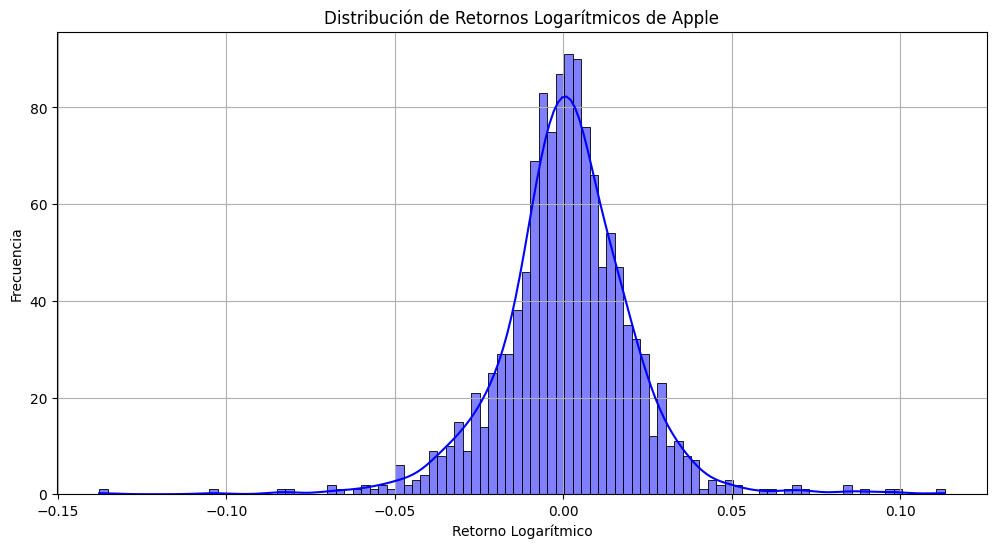

In [4]:
# Estadísticas descriptivas y propiedades de la distribución
# Primero calculamos los retornos logarítmicos usando los precios de cierre diarios. Se usan retornos logaritmicos porque son aditivos en el tiempo y facilitan el análisis estadístico.
# Después generamos estadísticas descriptivas para evaluar la distribución,
# incluyendo media, desviación estándar, asimetría (skewness) y curtosis.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular los retornos logarítmicos
returns = np.log(close_prices / close_prices.shift(1)).dropna()

# Mostrar estadísticas descriptivas
desc_stats = returns.describe().T
desc_stats['median'] = returns.median()
desc_stats['skewness'] = returns.skew() ##Sirve para medir el riesgo de un activo o su volatilidad, una alternativa a la desviación estándar.
desc_stats['kurtosis'] = returns.kurtosis() ##Mide la "cola" de la distribución, es decir, la probabilidad de eventos extremos osea si es mayor a 3 hay más probabilidad de eventos extremos.

print("Estadísticas Descriptivas de los Retornos Logarítmicos")
print(desc_stats)

# Graficar la distribución de los retornos logarítmicos de Apple
plt.figure(figsize=(12, 6))
sns.histplot(returns['AAPL'], bins=100, kde=True, color='blue')
plt.title('Distribución de Retornos Logarítmicos de Apple')
plt.xlabel('Retorno Logarítmico')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()


# Correlation and Cross-Asset Dynamics

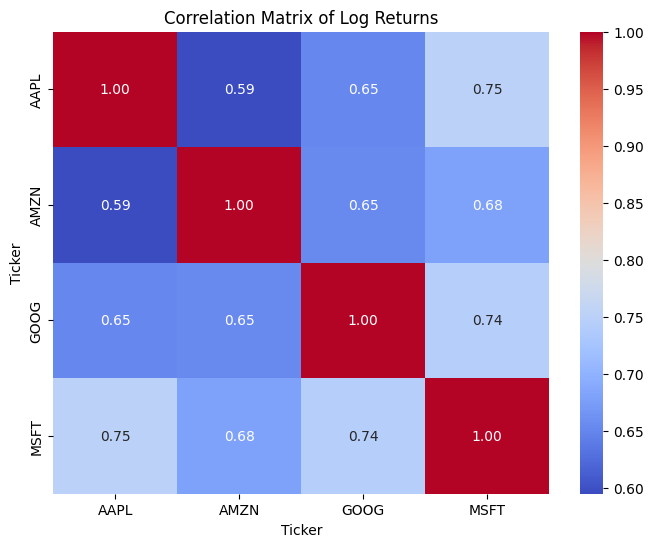

In [ ]:
##Observamos la correlation entre los retornos logarítmicos de las acciones.

corr_matrix = returns.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Log Returns')
plt.show()

# Volatility Tracking and Risk Dynamics

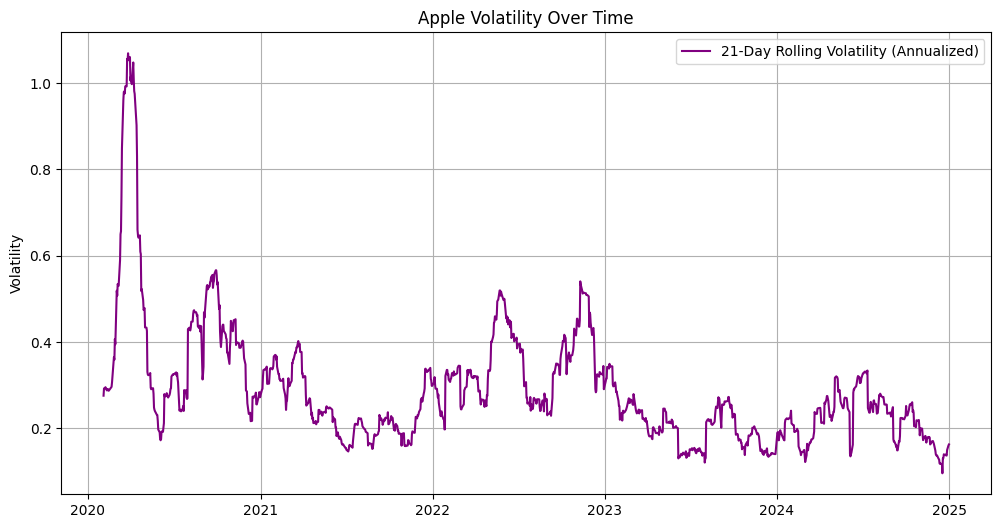

In [ ]:
##Nos ofrece como poder ver la volatilidad de una acción a lo largo del tiempo, lo cual es crucial para evaluar el riesgo asociado con la inversión en esa acción.
rolling_vol = returns['AAPL'].rolling(window=21).std() * np.sqrt(252)

plt.figure(figsize=(12, 6))
plt.plot(rolling_vol, label='21-Day Rolling Volatility (Annualized)', color='purple')
plt.title('Apple Volatility Over Time')
plt.ylabel('Volatility')
plt.grid(True)
plt.legend()
plt.show()

# Outlier and Anomaly Detection

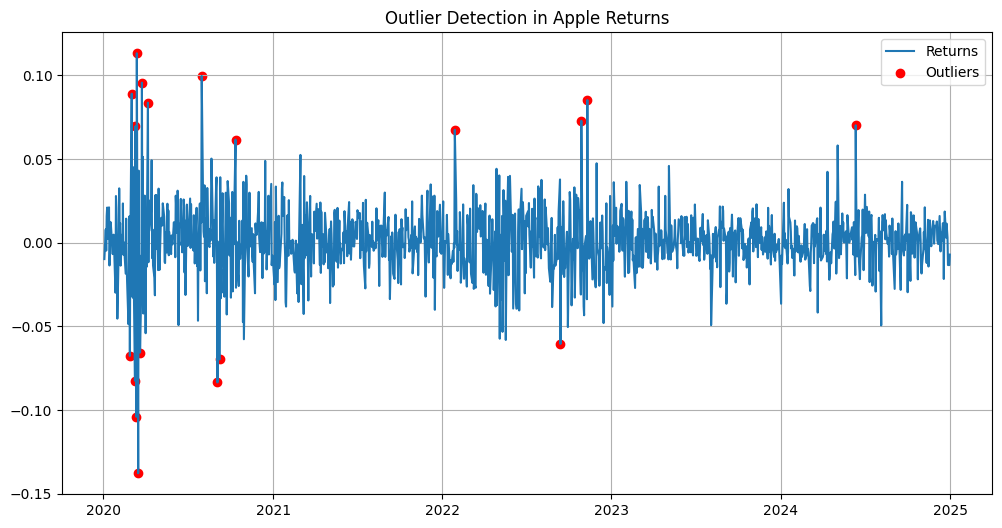

In [ ]:
##Aqui observamos los outliers en los retornos de Apple usando el método del Z-Score. 

from scipy.stats import zscore

returns['Z_Score'] = zscore(returns['AAPL'])
outliers = returns[np.abs(returns['Z_Score']) > 3]

plt.figure(figsize=(12, 6))
plt.plot(returns['AAPL'], label='Returns')
plt.scatter(outliers.index, outliers['AAPL'], color='red', label='Outliers')
plt.title('Outlier Detection in Apple Returns')
plt.legend()
plt.grid(True)
plt.show()

# Temporal Patterns, Seasonality & Regime Detection

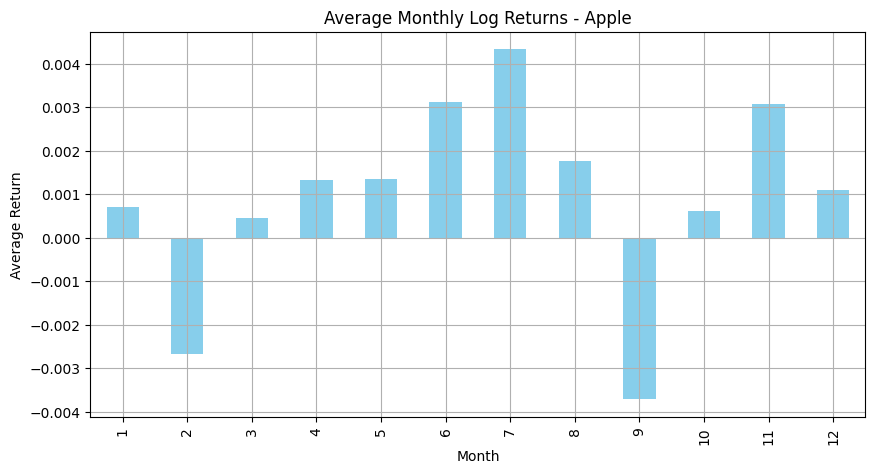

In [ ]:
##Aqui observamos que meses del año tienden a tener mejores o peores rendimientos promedio para Apple.

returns['Month'] = returns.index.month
monthly_avg = returns.groupby('Month').mean()

plt.figure(figsize=(10, 5))
monthly_avg['AAPL'].plot(kind='bar', color='skyblue')
plt.title('Average Monthly Log Returns - Apple')
plt.xlabel('Month')
plt.ylabel('Average Return')
plt.grid(True)
plt.show()

In [9]:
import yfinance as yf

# Download historical data explicitly specifying the adjusted close
aapl_data = yf.download('AAPL', start='2020-01-01', end='2025-03-26', auto_adjust=True)

# Now 'Close' represents adjusted close due to auto_adjust=True
returns = aapl_data[['Close']].pct_change().dropna()
returns.rename(columns={'Close': 'AAPL'}, inplace=True)

# Calculate rolling indicators
returns['Rolling_Max_20'] = returns['AAPL'].rolling(window=20).max()
returns['Momentum_5'] = returns['AAPL'] - returns['AAPL'].shift(5)
returns['Volatility_20'] = returns['AAPL'].rolling(window=20).std()

returns.dropna(inplace=True)

# Display the resulting DataFrame
returns.head()


[*********************100%***********************]  1 of 1 completed


Price,AAPL,Rolling_Max_20,Momentum_5,Volatility_20
Ticker,AAPL,,,
Date,,,,
2020-01-31,-0.044339,0.028289,-0.041457,0.017679
2020-02-03,-0.002746,0.028289,0.026659,0.017511
2020-02-04,0.033014,0.033014,0.004725,0.018808
2020-02-05,0.008154,0.033014,-0.012778,0.018741
2020-02-06,0.011697,0.033014,0.013146,0.018616
